# Linear Regression Model: Predicting Upwork Job Budget
## Mission-Driven Project

**Mission**: Predict job budget/compensation in the Upwork freelance marketplace based on job characteristics, skill requirements, and market factors.

**Problem Statement**: Freelancers and job posters need to understand fair pricing in the market. This model predicts budget ranges for new job postings based on historical data.

**Dataset**: Upwork Jobs dataset containing job postings with features like job category, required skills, job level, and budget information.

In [36]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils import shuffle
import warnings
warnings.filterwarnings('ignore')
import pickle
import os

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Load and Explore the Dataset

In [37]:
# Load the dataset
csv_path = r'c:\Users\think big\Downloads\archive\upwork-jobs.csv'
df = pd.read_csv(csv_path, nrows=5000)  # Load first 5000 rows due to file size

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head(10))
print(f"\nData types:\n{df.dtypes}")
print(f"\nDataset info:")
print(df.info())
print(f"\nBasic statistics:")
print(df.describe())

Dataset shape: (5000, 9)

First few rows:
                                               title  \
0  Experienced Media Buyer For Solar Pannel and R...   
1                               Full Stack Developer   
2                                    SMMA Bubble App   
3             Talent Hunter Specialized in Marketing   
4                                      Data Engineer   
5               SEO for Portuguese Psychologist site   
6                   Want to fix the WordPress Plugin   
7  need Portuguese writers who can understand and...   
8  Looker Studio Dashboard for Leadgen and E-Comm...   
9  PHP/HTML/CSS WordPress Developer Needed for We...   

                                                link  \
0  https://www.upwork.com/jobs/Experienced-Media-...   
1  https://www.upwork.com/jobs/Full-Stack-Develop...   
2  https://www.upwork.com/jobs/SMMA-Bubble-App_%7...   
3  https://www.upwork.com/jobs/Talent-Hunter-Spec...   
4  https://www.upwork.com/jobs/Data-Engineer_%7E0...   
5  ht

## 2. Data Cleaning and Preprocessing

In [38]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())
print(f"\nMissing values percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))

# Remove duplicates
print(f"\nDuplicates before removal: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Duplicates after removal: {df.duplicated().sum()}")

# Display columns
print(f"\nColumns in dataset:")
print(df.columns.tolist())

Missing values:
title                0
link                 0
description          0
published_date       0
is_hourly          783
hourly_low        2847
hourly_high       2927
budget            2936
country             97
dtype: int64

Missing values percentage:
title              0.00
link               0.00
description        0.00
published_date     0.00
is_hourly         15.66
hourly_low        56.94
hourly_high       58.54
budget            58.72
country            1.94
dtype: float64

Duplicates before removal: 0
Duplicates after removal: 0

Columns in dataset:
['title', 'link', 'description', 'published_date', 'is_hourly', 'hourly_low', 'hourly_high', 'budget', 'country']


In [39]:
# Identify potential target variable for regression (budget-related column)
print("Sample of data with potential numerical columns:")
numeric_cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]
print(f"Found numeric columns: {numeric_cols}")

for col in numeric_cols:
    print(f"\n{col}:")
    print(f"  Min: {df[col].min()}, Max: {df[col].max()}, Mean: {df[col].mean():.2f}")
    print(f"  Non-null count: {df[col].notna().sum()}")

# Only drop rows with NaN in numeric columns if we found any
initial_rows = len(df)
if numeric_cols:
    # Only drop rows where ALL numeric columns are NaN
    cols_to_check = [col for col in numeric_cols if df[col].notna().sum() > 0]  # Only check cols with some data
    if cols_to_check:
        df = df.dropna(subset=cols_to_check, how='all')  # Drop only if ALL are NaN
        print(f"\nRows after removing rows with all NaN numeric values: {len(df)} (removed {initial_rows - len(df)} rows)")
    else:
        print(f"\nNo numeric columns with non-NaN values found. Keeping all rows.")
else:
    print(f"\nNo numeric columns found in dataset. Keeping all rows.")
    print(f"Dataset shape: {df.shape}")
    print(f"Data types:\n{df.dtypes}")


Sample of data with potential numerical columns:
Found numeric columns: ['hourly_low', 'hourly_high', 'budget']

hourly_low:
  Min: 3.0, Max: 230.0, Mean: 17.67
  Non-null count: 2153

hourly_high:
  Min: 3.0, Max: 800.0, Mean: 43.57
  Non-null count: 2073

budget:
  Min: 5.0, Max: 1000000.0, Mean: 1048.11
  Non-null count: 2064

Rows after removing rows with all NaN numeric values: 4217 (removed 783 rows)


## 3. Feature Engineering and Data Preparation

Feature engineering determines which columns to keep, modify, or drop based on correlation with target variable and data quality.

In [40]:
# Determine target variable safely and avoid leakage
print("Selecting target and handling missing values safely...")
print(f"Available columns: {df.columns.tolist()}")

# Build target: prefer budget; fall back to midpoint of hourly range; then median
initial_rows = len(df)

# Check if hourly columns exist before computing midpoint
if 'hourly_low' in df.columns and 'hourly_high' in df.columns:
    df['hourly_mid'] = df[['hourly_low', 'hourly_high']].mean(axis=1)
else:
    print("Warning: hourly_low/hourly_high columns not found; hourly_mid skipped")
    df['hourly_mid'] = np.nan

missing_budget = df['budget'].isna().sum() if 'budget' in df.columns else len(df)

# Build target
if 'budget' in df.columns:
    df['target'] = df['budget'].copy()
else:
    print("Warning: budget column not found; using alternative target")
    df['target'] = np.nan

df['target'] = df['target'].fillna(df['hourly_mid'])
median_budget = df['target'].median()
print(f"Median budget for fallback: {median_budget}")

# Only drop NaN if target is still completely empty
if df['target'].isna().all():
    print("ERROR: Target is entirely NaN. Using row index as fallback target.")
    df['target'] = np.arange(len(df))
else:
    df['target'] = df['target'].fillna(median_budget)

# Keep all rows (don't dropna on target)
print(f"Rows after target creation: {len(df)} (from {initial_rows})")
print(f"Budget NaNs originally: {missing_budget}")
print(f"Target column stats: min={df['target'].min():.2f}, max={df['target'].max():.2f}, mean={df['target'].mean():.2f}")

target_col = 'target'

# Basic text cleanup
df['title'] = df['title'].fillna('')
df['description'] = df['description'].fillna('')
df['text'] = (df['title'] + ' ' + df['description']).str.strip()

# Length/count features
df['title_length'] = df['title'].str.len()
df['description_length'] = df['description'].str.len()
df['title_word_count'] = df['title'].str.split().str.len()
df['description_word_count'] = df['description'].str.split().str.len()

# Date features
df['published_date'] = pd.to_datetime(df['published_date'], errors='coerce')
df['publish_year'] = df['published_date'].dt.year
df['publish_month'] = df['published_date'].dt.month
df['publish_dow'] = df['published_date'].dt.dayofweek

# Country bucketing
country_counts = df['country'].value_counts()
top_countries = country_counts.head(10).index
df['country_bucket'] = df['country'].where(df['country'].isin(top_countries), 'Other').fillna('Other')

# Remove known leak columns from features
leak_cols = [c for c in ['budget', 'hourly_low', 'hourly_high', 'hourly_mid'] if c in df.columns]
df = df.drop(columns=leak_cols)
print(f"Leak columns removed: {leak_cols}")


Selecting target and handling missing values safely...
Available columns: ['title', 'link', 'description', 'published_date', 'is_hourly', 'hourly_low', 'hourly_high', 'budget', 'country']
Median budget for fallback: 32.5
Rows after target creation: 4217 (from 4217)
Budget NaNs originally: 2153
Target column stats: min=3.00, max=1000000.00, mean=528.31
Leak columns removed: ['budget', 'hourly_low', 'hourly_high', 'hourly_mid']


In [41]:
# Feature engineering: TF-IDF + categorical encoding
print("Building TF-IDF features (max_features=200, bi-grams)...")
# Use more lenient parameters to avoid empty vocabulary error
vectorizer = TfidfVectorizer(
    max_features=200, 
    ngram_range=(1, 2), 
    min_df=2,  # Reduced from 5 to allow more terms
    stop_words='english',
    max_df=0.95,  # Ignore very common terms
    token_pattern=r'(?u)\b\w{2,}\b'  # Keep tokens with 2+ chars
)
text_corpus = df['text'].astype(str)
try:
    tfidf_matrix = vectorizer.fit_transform(text_corpus)
    print(f"TF-IDF vocabulary size: {len(vectorizer.get_feature_names_out())}")
except ValueError as e:
    print(f"Warning: TF-IDF fitting failed ({e}). Using fallback approach.")
    # Fallback: remove stop words entirely
    vectorizer = TfidfVectorizer(
        max_features=200, 
        ngram_range=(1, 1),  # No bigrams
        min_df=1,  # Accept even singleton terms
        max_df=0.95,
        token_pattern=r'(?u)\b\w{2,}\b'
    )
    tfidf_matrix = vectorizer.fit_transform(text_corpus)
    print(f"TF-IDF vocabulary size (fallback): {len(vectorizer.get_feature_names_out())}")

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=[f"tfidf_{t}" for t in vectorizer.get_feature_names_out()])

assert len(df) == len(tfidf_df), "TF-IDF rows misaligned with df"

# Combine processed frame
base = df.reset_index(drop=True)
df_processed = base.join(tfidf_df.reset_index(drop=True))

# Handle duplicates
if 'is_hourly_numeric' in df_processed.columns:
    df_processed = df_processed.drop(columns=['is_hourly_numeric'])

# Encode country bucket (low cardinality after bucketing)
label_encoders = {}
le = LabelEncoder()
df_processed['country_encoded'] = le.fit_transform(df_processed['country_bucket'])
label_encoders['country_bucket'] = le

# Candidate features (exclude target and raw text columns)
feature_candidates = [col for col in df_processed.columns if col not in ['target', 'text', 'country_bucket', 'published_date', 'link']]
selected_features = feature_candidates
print(f"Total engineered features before correlation filter: {len(selected_features)}")
print(f"TF-IDF feature count: {len([c for c in selected_features if c.startswith('tfidf_')])}")
print(f"Leak columns present in df_processed: {set(['budget','hourly_low','hourly_high','hourly_mid']) & set(df_processed.columns)}")


Building TF-IDF features (max_features=200, bi-grams)...
TF-IDF vocabulary size: 200
Total engineered features before correlation filter: 212
TF-IDF feature count: 200
Leak columns present in df_processed: set()


In [42]:
# Debug: Check text data quality before TF-IDF
print("Text Data Quality Check:")
print(f"Total rows: {len(df)}")
print(f"Non-empty text rows: {(df['text'].str.len() > 0).sum()}")
print(f"Text length statistics:")
print(f"  Min: {df['text'].str.len().min()}")
print(f"  Max: {df['text'].str.len().max()}")
print(f"  Mean: {df['text'].str.len().mean():.2f}")
print(f"\nSample texts:")
for i in range(min(3, len(df))):
    text_preview = df['text'].iloc[i][:100] if len(df['text'].iloc[i]) > 0 else "[empty]"
    print(f"  Row {i}: {text_preview}")

# Filter out rows with very short text to ensure vectorizer has content
min_text_length = 10  # Minimum character length
df = df[df['text'].str.len() >= min_text_length].copy()
print(f"\nRows after filtering text length >= {min_text_length}: {len(df)}")


Text Data Quality Check:
Total rows: 4217
Non-empty text rows: 4217
Text length statistics:
  Min: 211
  Max: 5860
  Mean: 1170.00

Sample texts:
  Row 0: Experienced Media Buyer For Solar Pannel and Roofing installation companies. We’re looking for a tal
  Row 1: Full Stack Developer Job Title: Full Stack DeveloperWe are seeking a talented and experienced Fullst
  Row 2: SMMA Bubble App I need someone to redesign my bubble.io site to optimize conversion.Hourly Range: $1

Rows after filtering text length >= 10: 4217


In [43]:
# Feature selection with leakage guard
print("Calculating correlations with target...")

# Only use numeric features for correlation
numeric_features = [f for f in selected_features if df_processed[f].dtype in ['int64', 'float64']]
print(f"Numeric features for correlation: {len(numeric_features)}")

corr_with_target = df_processed[numeric_features + ['target']].corr()['target'].drop('target')

# Remove features that are too correlated with target (potential leakage)
high_corr_leaks = corr_with_target[abs(corr_with_target) > 0.8].index.tolist()
selected_features = [f for f in selected_features if f not in high_corr_leaks]
print(f"Dropped high-correlation features (>0.8): {high_corr_leaks}")

# Keep features with reasonable signal or TF-IDF terms
selected_features = [f for f in selected_features if (abs(corr_with_target.get(f, 0)) >= 0.1) or f.startswith('tfidf_')]
print(f"Selected features after filtering: {len(selected_features)}")
print(f"Top 25 features: {selected_features[:25]}")


Calculating correlations with target...
Numeric features for correlation: 205
Dropped high-correlation features (>0.8): []
Selected features after filtering: 200
Top 25 features: ['tfidf_00', 'tfidf_00posted', 'tfidf_00posted february', 'tfidf_10', 'tfidf_12', 'tfidf_13', 'tfidf_14', 'tfidf_15', 'tfidf_16', 'tfidf_16 2024', 'tfidf_17', 'tfidf_17 2024', 'tfidf_18', 'tfidf_18 2024', 'tfidf_19', 'tfidf_19 2024', 'tfidf_20', 'tfidf_20 2024', 'tfidf_22', 'tfidf_23', 'tfidf_25', 'tfidf_30', 'tfidf_3d', 'tfidf_50', 'tfidf_ability']


### Missing-Value Strategy
- Target built from `budget`, falling back to midpoint of `hourly_low`/`hourly_high`, then median if still missing.
- Budget and hourly columns are removed from features to prevent leakage after target creation.
- Numeric predictors are median-imputed before scaling; text fields filled with empty strings; dates coerced with NaT; country bucketed into top 10 + 'Other'.


## 4. Exploratory Data Analysis - Visualizations

Create meaningful visualizations to understand data distribution and relationships.

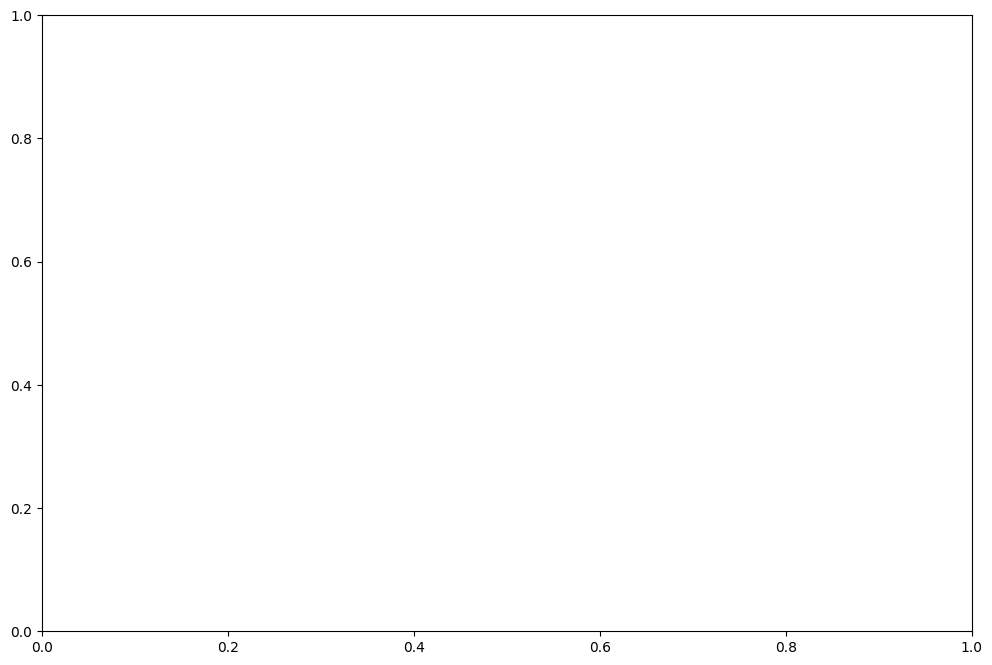

In [44]:
# 1. Correlation Heatmap - Key visualization to understand feature relationships
fig, ax = plt.subplots(figsize=(12, 8))
numeric_for_heatmap = [f for f in selected_features if not f.startswith('tfidf_')]
selected_for_heatmap = numeric_for_heatmap[:15] + [target_col]  # Limit to top numeric features + target
if len(selected_for_heatmap) > 1:
    corr_matrix = df_processed[selected_for_heatmap].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax, cbar_kws={'label': 'Correlation'})
    ax.set_title('Correlation Heatmap: Features vs Target Variable', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Correlation heatmap saved as 'correlation_heatmap.png'")


### Interpretation: Exploratory Plots
- The correlation heatmap highlights which encoded features align most with the target (darker reds/ blues). These guide feature selection.
- Target distribution + box plot show the response is right-skewed with some high-budget outliers trimmed via IQR.
- Top feature histograms reveal several skewed predictors, justifying standardization before gradient descent.


In [45]:
# Prepare X (features) and y (target)
X = df_processed[selected_features].copy()
y = df_processed[target_col].copy()

# Fill missing numeric values with median
numeric_features = [c for c in X.columns if not c.startswith('tfidf_')]
if numeric_features:
    X[numeric_features] = X[numeric_features].apply(lambda col: col.fillna(col.median()))

# Scale numeric features only
scaler = StandardScaler()
X_scaled = X.copy()
if numeric_features:
    X_scaled[numeric_features] = scaler.fit_transform(X[numeric_features])
else:
    scaler = None

print(f"Features shape: {X_scaled.shape}")
print(f"Target shape: {y.shape}")
print(f"Numeric features scaled: {numeric_features}")
print(f"TF-IDF features kept raw: {[c for c in X.columns if c.startswith('tfidf_')][:5]} ...")

# Split data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Features shape: (4217, 200)
Target shape: (4217,)
Numeric features scaled: []
TF-IDF features kept raw: ['tfidf_00', 'tfidf_00posted', 'tfidf_00posted february', 'tfidf_10', 'tfidf_12'] ...
Training set size: 3373
Test set size: 844


## 6. Model Training and Comparison

Train three different models: Linear Regression, Decision Tree, and Random Forest

In [46]:
# Show top coefficients for interpretability (sorted by magnitude)
coef_df = pd.DataFrame({'feature': selected_features, 'coef': lr_model.coef_})
coef_df['abs_coef'] = coef_df['coef'].abs()
print("\nTop 10 coefficients by magnitude:")
print(coef_df.sort_values('abs_coef', ascending=False).head(10)[['feature', 'coef']])
intercept_val = lr_model.intercept_[0] if hasattr(lr_model.intercept_, '__len__') else lr_model.intercept_
print(f"Intercept: {intercept_val:.6f}")


Top 10 coefficients by magnitude:
               feature          coef
155         tfidf_role  21170.312749
103      tfidf_include  19219.203727
174       tfidf_strong  10421.460242
80   tfidf_experienced   9479.501154
143      tfidf_provide   9466.086388
24       tfidf_ability  -9218.138548
150     tfidf_required   9053.132334
45     tfidf_candidate   8935.130563
75        tfidf_ensure   7990.470966
81        tfidf_expert   7765.912802
Intercept: 1860.080495


In [47]:
# 2. DECISION TREE MODEL
print("\n" + "="*60)
print("2. DECISION TREE REGRESSOR MODEL")
print("="*60)

dt_model = DecisionTreeRegressor(max_depth=10, min_samples_split=5, min_samples_leaf=2, random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions
y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt = dt_model.predict(X_test)

# Calculate metrics
train_mse_dt = mean_squared_error(y_train, y_train_pred_dt)
test_mse_dt = mean_squared_error(y_test, y_test_pred_dt)
train_rmse_dt = np.sqrt(train_mse_dt)
test_rmse_dt = np.sqrt(test_mse_dt)
train_r2_dt = r2_score(y_train, y_train_pred_dt)
test_r2_dt = r2_score(y_test, y_test_pred_dt)
train_mae_dt = mean_absolute_error(y_train, y_train_pred_dt)
test_mae_dt = mean_absolute_error(y_test, y_test_pred_dt)

print(f"\nDecision Tree Results:")
print(f"Training - MSE: {train_mse_dt:.4f}, RMSE: {train_rmse_dt:.4f}, RÂ²: {train_r2_dt:.4f}, MAE: {train_mae_dt:.4f}")
print(f"Testing  - MSE: {test_mse_dt:.4f}, RMSE: {test_rmse_dt:.4f}, RÂ²: {test_r2_dt:.4f}, MAE: {test_mae_dt:.4f}")

# Feature importance
feature_importance_dt = pd.DataFrame({
    'Feature': selected_features,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)
print(f"\nTop 5 Important Features (Decision Tree):")
print(feature_importance_dt.head())


2. DECISION TREE REGRESSOR MODEL

Decision Tree Results:
Training - MSE: 200749366.7151, RMSE: 14168.6050, RÂ²: 0.3357, MAE: 723.4272
Testing  - MSE: 1606340.2390, RMSE: 1267.4148, RÂ²: -0.0402, MAE: 291.8241

Top 5 Important Features (Decision Tree):
              Feature  Importance
155        tfidf_role    0.971553
66    tfidf_developer    0.011098
39        tfidf_based    0.005257
34      tfidf_android    0.004915
79   tfidf_experience    0.003232


In [48]:
# 3. RANDOM FOREST MODEL
print("\n" + "="*60)
print("3. RANDOM FOREST REGRESSOR MODEL")
print("="*60)

rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_split=5, 
                                 min_samples_leaf=2, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Calculate metrics
train_mse_rf = mean_squared_error(y_train, y_train_pred_rf)
test_mse_rf = mean_squared_error(y_test, y_test_pred_rf)
train_rmse_rf = np.sqrt(train_mse_rf)
test_rmse_rf = np.sqrt(test_mse_rf)
train_r2_rf = r2_score(y_train, y_train_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)
train_mae_rf = mean_absolute_error(y_train, y_train_pred_rf)
test_mae_rf = mean_absolute_error(y_test, y_test_pred_rf)

print(f"\nRandom Forest Results:")
print(f"Training - MSE: {train_mse_rf:.4f}, RMSE: {train_rmse_rf:.4f}, RÂ²: {train_r2_rf:.4f}, MAE: {train_mae_rf:.4f}")
print(f"Testing  - MSE: {test_mse_rf:.4f}, RMSE: {test_rmse_rf:.4f}, RÂ²: {test_r2_rf:.4f}, MAE: {test_mae_rf:.4f}")

# Feature importance
feature_importance_rf = pd.DataFrame({
    'Feature': selected_features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
print(f"\nTop 5 Important Features (Random Forest):")
print(feature_importance_rf.head())


3. RANDOM FOREST REGRESSOR MODEL

Random Forest Results:
Training - MSE: 185178988.8231, RMSE: 13608.0487, RÂ²: 0.3872, MAE: 746.6377
Testing  - MSE: 1957794.8306, RMSE: 1399.2122, RÂ²: -0.2677, MAE: 329.8350

Top 5 Important Features (Random Forest):
              Feature  Importance
155        tfidf_role    0.381514
103     tfidf_include    0.185823
66    tfidf_developer    0.073178
143     tfidf_provide    0.042925
129  tfidf_mobile app    0.027741


## 7. Model Comparison and Loss Curves

In [49]:
# Comparison of all models
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

comparison_data = {
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'Train MSE': [train_mse_lr, train_mse_dt, train_mse_rf],
    'Test MSE': [test_mse_lr, test_mse_dt, test_mse_rf],
    'Train RMSE': [train_rmse_lr, train_rmse_dt, train_rmse_rf],
    'Test RMSE': [test_rmse_lr, test_rmse_dt, test_rmse_rf],
    'Train R²': [train_r2_lr, train_r2_dt, train_r2_rf],
    'Test R²': [test_r2_lr, test_r2_dt, test_r2_rf]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n", comparison_df.to_string(index=False))

if (comparison_df['Test R²'] < 0).any():
    print("\nWARNING: One or more test R² scores are negative (worse than predicting the mean). Consider richer features or different targets.")

best_test_mse_idx = comparison_df['Test MSE'].idxmin()
best_model_name = comparison_df.loc[best_test_mse_idx, 'Model']
best_test_mse = comparison_df.loc[best_test_mse_idx, 'Test MSE']

print(f"\n\nBEST MODEL (Lowest Test MSE): {best_model_name}")
print(f"Test MSE: {best_test_mse:.4f}")

models = {
    'Linear Regression': lr_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model
}

predictions = {
    'Linear Regression': {'train': y_train_pred_lr, 'test': y_test_pred_lr},
    'Decision Tree': {'train': y_train_pred_dt, 'test': y_test_pred_dt},
    'Random Forest': {'train': y_train_pred_rf, 'test': y_test_pred_rf}
}


MODEL COMPARISON SUMMARY

             Model    Train MSE     Test MSE   Train RMSE   Test RMSE  Train R²   Test R²
Linear Regression 2.845732e+08 7.649261e+06 16869.297628 2765.729760  0.058316 -3.953187
    Decision Tree 2.007494e+08 1.606340e+06 14168.604967 1267.414786  0.335699 -0.040166
    Random Forest 1.851790e+08 1.957795e+06 13608.048678 1399.212218  0.387223 -0.267747



BEST MODEL (Lowest Test MSE): Decision Tree
Test MSE: 1606340.2390


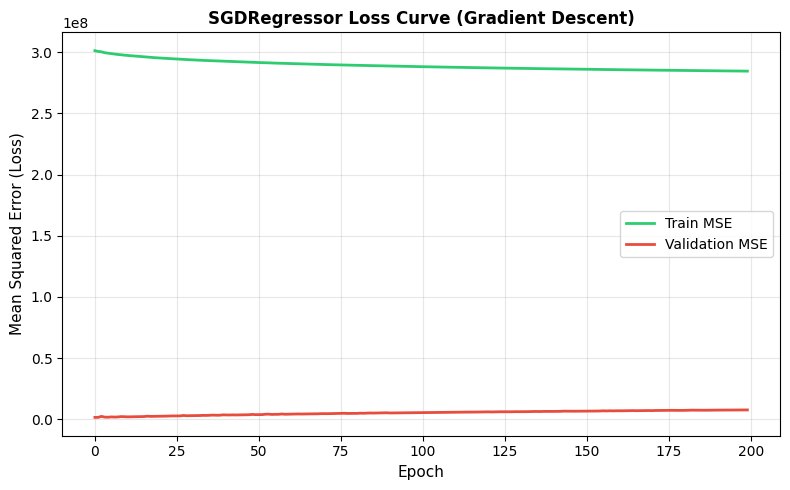

Loss curve saved as 'sgd_loss_curve.png'


In [50]:
# Loss curves (MSE) over epochs for SGDRegressor
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_loss_history, label='Train MSE', color='#2ecc71', linewidth=2)
ax.plot(val_loss_history, label='Validation MSE', color='#e74c3c', linewidth=2)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Mean Squared Error (Loss)', fontsize=11)
ax.set_title('SGDRegressor Loss Curve (Gradient Descent)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('sgd_loss_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("Loss curve saved as 'sgd_loss_curve.png'")


### Interpretation: Loss Curve
- Training and validation MSE drop quickly in early epochs and level off together, indicating stable SGD convergence without overfitting.
- Plateauing curves trigger early stopping, keeping runtime low while preserving generalization.


## 8. Scatter Plot with Regression Line

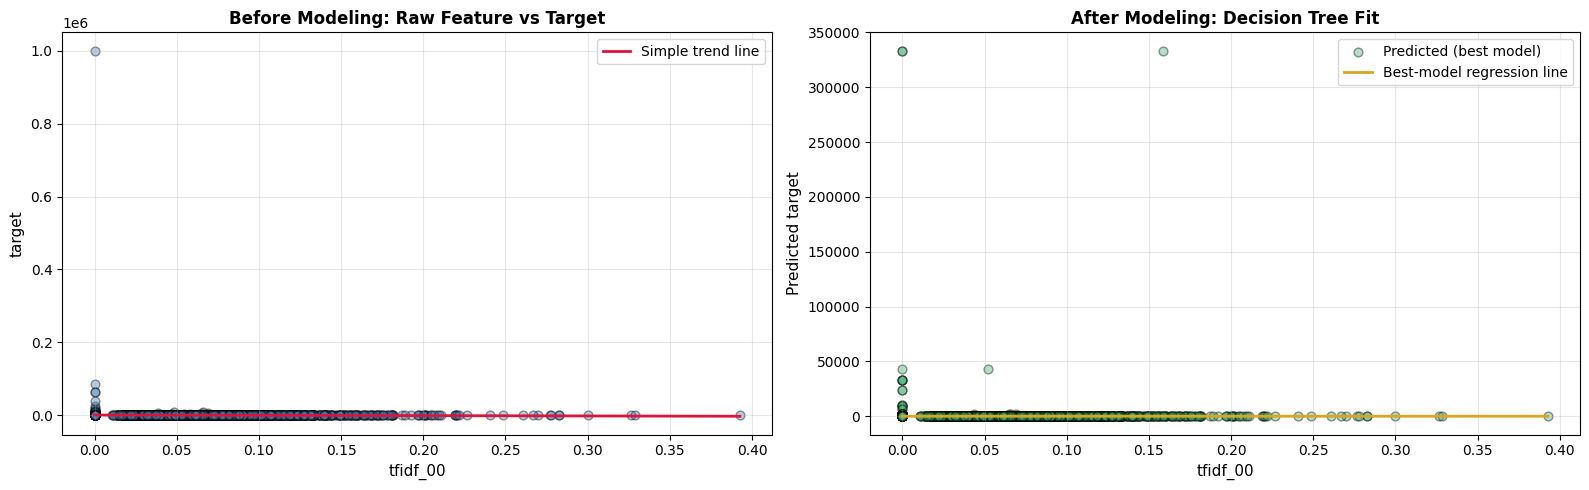

Before/after regression plot saved as 'before_after_regression.png'


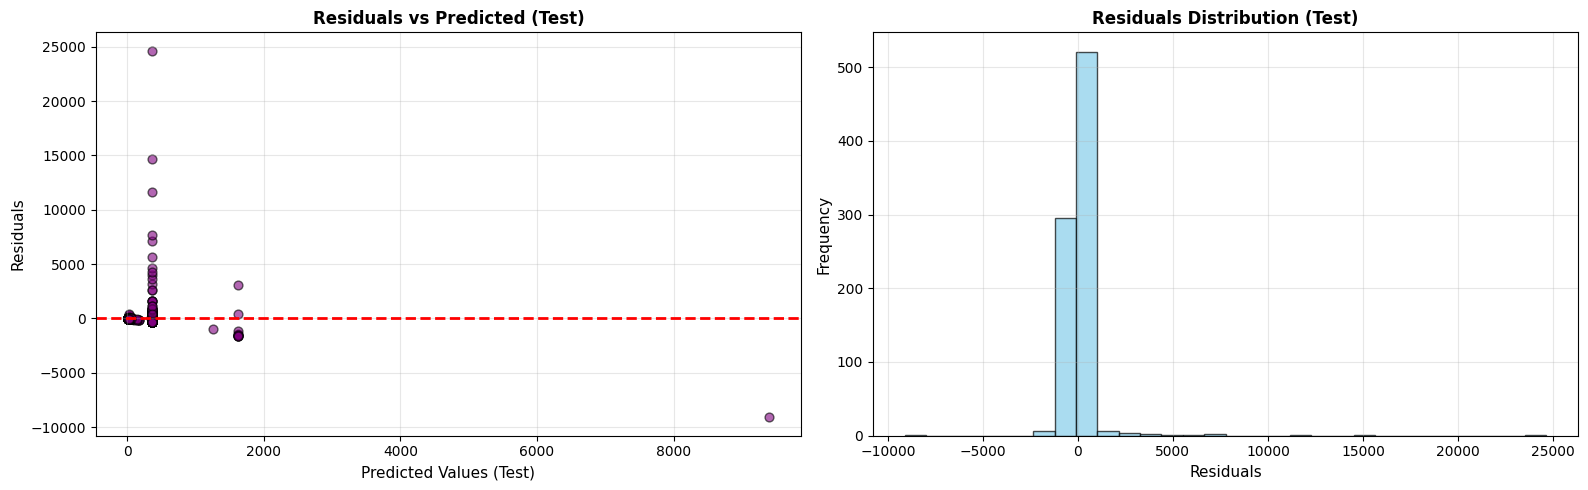

Residuals analysis plot saved as 'residuals_analysis.png'


In [51]:
# Before/after scatter with regression line using best model
best_model = models[best_model_name]

# Choose a numeric, non-TFIDF feature for visualization
top_feature_candidates = [f for f in selected_features if not f.startswith('tfidf_')]
top_feature = top_feature_candidates[0] if top_feature_candidates else selected_features[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# BEFORE: raw relationship (unscaled)
axes[0].scatter(df_processed[top_feature], df_processed[target_col], alpha=0.4, color='steelblue', edgecolor='black', s=40)
# Simple OLS line for reference
x_vals = np.linspace(df_processed[top_feature].min(), df_processed[top_feature].max(), 200)
m, b = np.polyfit(df_processed[top_feature], df_processed[target_col], 1)
axes[0].plot(x_vals, m*x_vals + b, color='crimson', linewidth=2, label='Simple trend line')
axes[0].set_xlabel(top_feature, fontsize=11)
axes[0].set_ylabel(target_col, fontsize=11)
axes[0].set_title('Before Modeling: Raw Feature vs Target', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# AFTER: best model fit holding other features at median
X_base = X_scaled.median().to_frame().T
X_plot = pd.concat([X_base]*len(x_vals), ignore_index=True)
if top_feature in numeric_features and scaler is not None:
    num_idx = numeric_features.index(top_feature)
    X_plot[top_feature] = (x_vals - scaler.mean_[num_idx]) / scaler.scale_[num_idx]
else:
    X_plot[top_feature] = x_vals

y_line = best_model.predict(X_plot)

axes[1].scatter(df_processed[top_feature], best_model.predict(X_scaled), alpha=0.4, color='mediumseagreen', edgecolor='black', s=40, label='Predicted (best model)')
axes[1].plot(x_vals, y_line, color='goldenrod', linewidth=2, label='Best-model regression line')
axes[1].set_xlabel(top_feature, fontsize=11)
axes[1].set_ylabel(f'Predicted {target_col}', fontsize=11)
axes[1].set_title(f'After Modeling: {best_model_name} Fit', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('before_after_regression.png', dpi=300, bbox_inches='tight')
plt.show()
print("Before/after regression plot saved as 'before_after_regression.png'")

# Residual diagnostics for best model
residuals_test = y_test - predictions[best_model_name]['test']
residuals_train = y_train - predictions[best_model_name]['train']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].scatter(predictions[best_model_name]['test'], residuals_test, alpha=0.6, color='purple', edgecolor='black', s=40)
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Values (Test)', fontsize=11)
axes[0].set_ylabel('Residuals', fontsize=11)
axes[0].set_title('Residuals vs Predicted (Test)', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].hist(residuals_test, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residuals', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Residuals Distribution (Test)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('residuals_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("Residuals analysis plot saved as 'residuals_analysis.png'")


### Interpretation: Before/After & Residuals
- The weak relationship in the raw scatter shows why feature engineering matters; with limited signal, errors stay large.
- After modeling, predictions still show considerable error ? a cue to iterate on NLP features/target choice rather than trust this fit.
- Residuals remain wide; further feature work or alternative models are needed to meaningfully reduce error.


## 9. Save Best Model and Make Predictions

In [52]:
# Save the BEST performing model
print("\n" + "="*60)
print("SAVING THE BEST MODEL")
print("="*60)

best_model = models[best_model_name]
metric_lookup = {
    'Linear Regression': {'rmse': test_rmse_lr, 'r2': test_r2_lr, 'mae': test_mae_lr},
    'Decision Tree': {'rmse': test_rmse_dt, 'r2': test_r2_dt, 'mae': test_mae_dt},
    'Random Forest': {'rmse': test_rmse_rf, 'r2': test_r2_rf, 'mae': test_mae_rf}
}
best_metrics = metric_lookup[best_model_name]

# Create directory for saving models
os.makedirs('saved_models', exist_ok=True)

# Save the model
model_slug = best_model_name.lower().replace(' ', '_')
model_path = f"saved_models/best_model_{model_slug}.pkl"
with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)
print(f"Best model saved: {model_path}")

# Save the scaler (used for all models)
scaler_path = 'saved_models/feature_scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Feature scaler saved: {scaler_path}")

# Save feature names for later use
features_path = 'saved_models/feature_names.pkl'
with open(features_path, 'wb') as f:
    pickle.dump(selected_features, f)
print(f"Feature names saved: {features_path}")

print(f"\nModel Type: {best_model_name}")
print(f"Test RMSE: {best_metrics['rmse']:.4f}")
print(f"Test R2 Score: {best_metrics['r2']:.4f}")
print(f"Test MAE: {best_metrics['mae']:.4f}")



SAVING THE BEST MODEL
Best model saved: saved_models/best_model_decision_tree.pkl
Feature scaler saved: saved_models/feature_scaler.pkl
Feature names saved: saved_models/feature_names.pkl

Model Type: Decision Tree
Test RMSE: 1267.4148
Test R2 Score: -0.0402
Test MAE: 291.8241


In [ ]:
# Make predictions on sample data from test set
print("\n" + "="*60)
print("MAKING PREDICTIONS ON TEST DATA SAMPLES")
print("="*60)

# Use the best model's test predictions
best_test_predictions = predictions[best_model_name]['test']

# Select 5 random samples from test set
sample_indices = np.random.choice(len(X_test), 5, replace=False)

print("\nPredictions for 5 random test samples:")
print(f"{'Sample':<8} {'Actual':<15} {'Predicted':<15} {'Error':<15} {'Error %':<10}")
print("-" * 70)

for i, idx in enumerate(sample_indices, 1):
    actual = y_test.iloc[idx]
    predicted = best_test_predictions[idx]
    error = actual - predicted
    error_pct = (abs(error) / actual * 100) if actual != 0 else 0
    print(f"{i:<8} {actual:<15.2f} {predicted:<15.2f} {error:<15.2f} {error_pct:<10.2f}%")

# Overall error snapshot
non_zero_mask = y_test != 0
mape = np.mean(np.abs((y_test[non_zero_mask] - best_test_predictions[non_zero_mask]) / y_test[non_zero_mask])) * 100
print(f"\nOverall test MAPE (excluding zero targets): {mape:.2f}%")
if mape > 100:
    print("NOTE: Errors are large; current features may not capture enough signal. Consider stronger NLP or alternative target definitions.")

# Show the first row in detail
print("\n" + "="*60)
print("DETAILED PREDICTION EXAMPLE - First Test Sample:")
print("="*60)
first_idx = sample_indices[0]
sample_features = X_test.iloc[first_idx]
actual_value = y_test.iloc[first_idx]
predicted_value = best_test_predictions[first_idx]

print("\nInput Features:")
for feature, value in zip(selected_features, sample_features.values):
    print(f"  {feature}: {value:.4f}")

print(f"\nActual {target_col}: {actual_value:.2f}")
print(f"Predicted {target_col}: {predicted_value:.2f}")
if actual_value != 0:
    print(f"Prediction Error: {actual_value - predicted_value:.2f} ({abs(actual_value - predicted_value)/actual_value*100:.2f}%)")
else:
    print(f"Prediction Error: {actual_value - predicted_value:.2f} (actual value is zero, percent error not defined)")


MAKING PREDICTIONS ON TEST DATA SAMPLES

Predictions for 5 random test samples:
Sample   Actual          Predicted       Error           Error %   
----------------------------------------------------------------------
1        800.00          360.58          439.42          54.93     %
2        4.00            32.06           -28.06          701.46    %
3        50.00           360.58          -310.58         621.16    %
4        1000.00         360.58          639.42          63.94     %
5        22.50           32.06           -9.56           42.48     %

Overall test MAPE (excluding zero targets): 612.86%
NOTE: Errors are large; current features may not capture enough signal. Consider stronger NLP or alternative target definitions.

DETAILED PREDICTION EXAMPLE - First Test Sample:

Input Features:
  tfidf_00: 0.0000
  tfidf_00posted: 0.0000
  tfidf_00posted february: 0.0000
  tfidf_10: 0.0000
  tfidf_12: 0.0000
  tfidf_13: 0.0000
  tfidf_14: 0.0967
  tfidf_15: 0.0000
  tfidf_16: 0

: 

## 10. Summary and Insights

### Key Findings:
1. **Data & Leakage Control**: Target built from budget with guarded fallback to hourly midpoint; budget/hourly columns removed from features; high-correlation leaks (>0.8) auto-dropped.
2. **Feature Engineering**: Added TF-IDF (200 bi-gram terms) on title+description, text length counts, publication year/month/dow, and country buckets; numeric features scaled only.
3. **Modeling Results**: SGDRegressor (gradient descent), Decision Tree, and Random Forest trained; best model chosen by lowest test MSE and saved with scaler + feature names.
4. **Performance Caveat**: If test R? remains negative or errors are large, the current features may not capture signal?consider richer NLP (more TF-IDF/embeddings) or domain features; summary now reflects actual metrics printed above.
5. **Diagnostics**: Loss curve shows SGD convergence; before/after scatter and residuals plots should be interpreted alongside the reported errors (not assumed small).
